In [2]:
library(tidyverse)
library(dplyr)
library(ggplot2)

players  <- read.csv("players.csv")
sessions <- read.csv("sessions.csv")

head(players)
head(sessions)
summary(players)
summary(sessions)

,experience,subscribe,hashedEmail,played_hours,name,gender,Age
,<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<int>
1,Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
2,Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
3,Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
4,Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
5,Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
6,Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


,hashedEmail,start_time,end_time,original_start_time,original_end_time
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
2,36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
3,f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
4,bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
5,36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
6,bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12


  experience        subscribe       hashedEmail         played_hours    
 Length:196         Mode :logical   Length:196         Min.   :  0.000  
 Class :character   FALSE:52        Class :character   1st Qu.:  0.000  
 Mode  :character   TRUE :144       Mode  :character   Median :  0.100  
                                                       Mean   :  5.846  
                                                       3rd Qu.:  0.600  
                                                       Max.   :223.100  
                                                                        
     name              gender               Age       
 Length:196         Length:196         Min.   : 9.00  
 Class :character   Class :character   1st Qu.:17.00  
 Mode  :character   Mode  :character   Median :19.00  
                                       Mean   :21.14  
                                       3rd Qu.:22.75  
                                       Max.   :58.00  
                               

 hashedEmail         start_time          end_time         original_start_time
 Length:1535        Length:1535        Length:1535        Min.   :1.712e+12  
 Class :character   Class :character   Class :character   1st Qu.:1.716e+12  
 Mode  :character   Mode  :character   Mode  :character   Median :1.719e+12  
                                                          Mean   :1.719e+12  
                                                          3rd Qu.:1.722e+12  
                                                          Max.   :1.727e+12  
                                                                             
 original_end_time  
 Min.   :1.712e+12  
 1st Qu.:1.716e+12  
 Median :1.719e+12  
 Mean   :1.719e+12  
 3rd Qu.:1.722e+12  
 Max.   :1.727e+12  
 NA's   :2          

## (1) Data Description

### Dataset Overview

| File | Rows (Observations) | Columns (Variables) | Description |
|------|----------------------|---------------------|--------------|
| `players.csv` | 196 | 7 | Player-level demographics and overall play summary |
| `sessions.csv` | 1,535 | 5 | Session-level time data (start and end timestamps) |

---

### Variables in Each File

| Dataset | Variable | Type | Description | Summary |
|----------|-----------|------|-------------|----------|
| **players.csv** | `experience` | Character | Player's experience level (`Beginner`, `Regular`, `Pro`, etc.) | 196 obs |
|  | `subscribe` | Logical | Whether player subscribed to newsletter (`TRUE`/`FALSE`) | 144 TRUE, 52 FALSE |
|  | `hashedEmail` | Character | Hashed email address (unique ID) | Unique across players |
|  | `played_hours` | Double | Total hours played | Mean = 5.85, Max = 223.10 |
|  | `name` | Character | Player name | Text |
|  | `gender` | Character | Player gender (`Male`, `Female`, `Other`) | 196 obs |
|  | `Age` | Integer | Player age in years | Mean = 21.14, Range = 9–58 |
| **sessions.csv** | `hashedEmail` | Character | Player ID linking sessions to players | 1,535 obs |
|  | `start_time` | Character | Session start time (ms since epoch) | Requires conversion |
|  | `end_time` | Character | Session end time (ms since epoch) | Requires conversion |
|  | `original_start_time` | Character | Raw start timestamp | NA’s = 2 |
|  | `original_end_time` | Character | Raw end timestamp | NA’s = 2 |

---

## Key Notes

Both datasets link through hashedEmail, which uniquely identifies each player. Timestamps are stored in milliseconds and must be converted into readable time units for analysis. The datasets differ in detail: players.csv summarizes player-level data, while sessions.csv records each game session.

## Data Direct and Potential Issues

Some timestamps and ages are missing, and a few players show unusually long play durations, indicating outliers. Time data are formatted as numeric values that require conversion. Potential hidden issues include sampling bias toward highly active players, possible time-zone inconsistencies, and duplicate entries caused by reconnections or network interruptions.

### (2) Question
Which kinds of players are most likely to contribute a large amount of data (i.e., play for a long time)?

### Specific Predictive Question
Can **early play behaviour**, such as the **number of sessions** and **average session duration** in the first 7 days, predict whether a player becomes a **high contributor** (top 25% of total play time)?

### Variables and Data Use

The response variable is high_contributor, a binary indicator where 1 represents players in the top 25% of total minutes played. The explanatory variables include the number of early sessions within the first seven days (sessions_n_early) and the average duration of those sessions (avg_duration_early).

Data from sessions.csv are used to calculate total and early playtime for each player, while players.csv provides demographic information such as gender and experience. Combining both datasets helps examine how early engagement predicts long-term player contribution.

### (3) Exploratory Data Analysis and Visualization

In [7]:
# 1) per-session duration (minutes) from epoch ms
sessions_clean <- sessions |>
  mutate(duration_min = (original_end_time - original_start_time) / (1000 * 60)) |>
  filter(!is.na(duration_min), duration_min > 0)

# 2) first-seen time per player (epoch ms)
t0_tbl <- sessions_clean |>
  group_by(hashedEmail) |>
  summarise(t0 = min(original_start_time), .groups = "drop")

# 3) keep ONLY sessions in the first 7 days after t0
seven_days_ms <- 7 * 24 * 60 * 60 * 1000
sessions_early <- sessions_clean |>
  inner_join(t0_tbl, by = "hashedEmail") |>
  filter(original_start_time >= t0,
         original_start_time <  t0 + seven_days_ms)
head(sessions_clean)
head(t0_tbl)
head(sessions_early)

,hashedEmail,start_time,end_time,original_start_time,original_end_time,duration_min
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,ad6390295640af1ed0e45ffc58a53b2d9074b0eea694b16210addd44d7c81f83,21/09/2024 02:13,21/09/2024 02:30,1.72688e+12,1.72689e+12,166.6667
2,b622593d2ef8b337dc554acb307d04a88114f2bf453b18fb5d2c80052aeb2319,18/08/2024 00:51,18/08/2024 03:15,1.72394e+12,1.72395e+12,166.6667
3,fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,31/07/2024 02:58,31/07/2024 03:21,1.72239e+12,1.72240e+12,166.6667
4,bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,04/07/2024 02:25,04/07/2024 04:05,1.72006e+12,1.72007e+12,166.6667
5,b622593d2ef8b337dc554acb307d04a88114f2bf453b18fb5d2c80052aeb2319,30/06/2024 16:21,30/06/2024 20:32,1.71976e+12,1.71978e+12,333.3333
6,c57fa94e436cf49a929d0168e47d26fec3d900b321775e280ef136979c01d5a4,08/09/2024 19:43,08/09/2024 20:07,1.72582e+12,1.72583e+12,166.6667


hashedEmail,t0
<chr>,<dbl>
0088b5e134c3f0498a18c7ea6b8d77b4b0ff1636fc93355ccc95b45423367832,1.71642e+12
0d4d71be33e2bc7266ee4983002bd930f69d304288a8663529c875f40f1750f3,1.72490e+12
0d70dd9cac34d646c810b1846fe6a85b9e288a76f5dcab9c1ff1a0e7ca200b3a,1.71372e+12
18936844e06b6c7871dce06384e2d142dd86756941641ef39cf40a9967ea14e3,1.71925e+12
22a78bfd44e46931261d06864b92cf9a8fd77fb02bec66cb71646dd9da222a0d,1.72264e+12
24d4892c2c3ce11d3e54c3bf31ee218901cac7a2f564911d67424c8fdf0874fe,1.71365e+12


,hashedEmail,start_time,end_time,original_start_time,original_end_time,duration_min,t0
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,b622593d2ef8b337dc554acb307d04a88114f2bf453b18fb5d2c80052aeb2319,30/06/2024 16:21,30/06/2024 20:32,1.71976e+12,1.71978e+12,333.3333,1.71962e+12
2,b622593d2ef8b337dc554acb307d04a88114f2bf453b18fb5d2c80052aeb2319,01/07/2024 21:53,02/07/2024 02:05,1.71987e+12,1.71989e+12,333.3333,1.71962e+12
3,d13020f8d53c08c95e64f2254424a65c9c479fcfd866b21b850d200a2689a8b5,21/08/2024 04:14,21/08/2024 04:42,1.72421e+12,1.72422e+12,166.6667,1.72421e+12
4,d46bd29a2ed08e3500bd8729085ef4b6f0ca65baf4c756f88b6bedf7a18e0352,03/09/2024 05:43,03/09/2024 07:33,1.72534e+12,1.72535e+12,166.6667,1.72534e+12
5,fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,16/04/2024 05:21,16/04/2024 05:33,1.71324e+12,1.71325e+12,166.6667,1.71324e+12
6,9782452b8e41d1f140374eec34c84f464df6ed12e2777e5b4f7150912b8ab78c,28/05/2024 07:31,28/05/2024 09:41,1.71688e+12,1.71689e+12,166.6667,1.71686e+12


In [8]:
# EARLY predictors (first week)
per_player_early <- sessions_early |>
  group_by(hashedEmail) |>
  summarise(
    sessions_n_early    = n(),
    avg_duration_early  = mean(duration_min),
    total_minutes_early = sum(duration_min),
    .groups = "drop"
  )

# OVERALL contribution (target)
per_player_overall <- sessions_clean |>
  group_by(hashedEmail) |>
  summarise(
    total_minutes_all = sum(duration_min),
    .groups = "drop"
  )

# join with players
dat <- players |>
  inner_join(per_player_overall, by = "hashedEmail") |>
  inner_join(per_player_early,   by = "hashedEmail")

head(per_player_early)
head(per_player_overall)
head(dat)

hashedEmail,sessions_n_early,avg_duration_early,total_minutes_early
<chr>,<int>,<dbl>,<dbl>
0088b5e134c3f0498a18c7ea6b8d77b4b0ff1636fc93355ccc95b45423367832,1,166.6667,166.6667
0d4d71be33e2bc7266ee4983002bd930f69d304288a8663529c875f40f1750f3,4,166.6667,666.6667
0d70dd9cac34d646c810b1846fe6a85b9e288a76f5dcab9c1ff1a0e7ca200b3a,1,166.6667,166.6667
18936844e06b6c7871dce06384e2d142dd86756941641ef39cf40a9967ea14e3,1,166.6667,166.6667
22a78bfd44e46931261d06864b92cf9a8fd77fb02bec66cb71646dd9da222a0d,1,166.6667,166.6667
24d4892c2c3ce11d3e54c3bf31ee218901cac7a2f564911d67424c8fdf0874fe,3,166.6667,500.0000


hashedEmail,total_minutes_all
<chr>,<dbl>
0088b5e134c3f0498a18c7ea6b8d77b4b0ff1636fc93355ccc95b45423367832,166.6667
0d4d71be33e2bc7266ee4983002bd930f69d304288a8663529c875f40f1750f3,666.6667
0d70dd9cac34d646c810b1846fe6a85b9e288a76f5dcab9c1ff1a0e7ca200b3a,166.6667
18936844e06b6c7871dce06384e2d142dd86756941641ef39cf40a9967ea14e3,1000.0000
22a78bfd44e46931261d06864b92cf9a8fd77fb02bec66cb71646dd9da222a0d,166.6667
24d4892c2c3ce11d3e54c3bf31ee218901cac7a2f564911d67424c8fdf0874fe,1833.3333


,experience,subscribe,hashedEmail,played_hours,name,gender,Age,total_minutes_all,sessions_n_early,avg_duration_early,total_minutes_early
,<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>
1,Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,2000.0000,1,166.6667,166.6667
2,Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17,166.6667,1,166.6667,166.6667
3,Amateur,TRUE,a175d4741dc84e6baf77901f6e8e0a06f54809a34e6b5211159bced346f7fb3e,48.4,Xander,Female,17,3000.0000,2,166.6667,333.3333
4,Regular,TRUE,bc704ff2bc676dbf48ee41b9e11481c1387bf758ad318f2428f336e3fecc6660,0.3,Andy,Male,58,166.6667,1,166.6667,166.6667
5,Amateur,TRUE,4b01bce3f141289709e8278b02ba5d2aaa7105d7ccb9c7deb37670a80e332774,1.8,Luca,Male,23,166.6667,1,166.6667,166.6667
6,Beginner,TRUE,f459ce1862ec9a43b6c714810390dfd632ed104eb11378b3a2a134b1b107bc75,0.6,Jabari,Male,26,166.6667,1,166.6667,166.6667


In [9]:
# sort by overall total minutes
dat_sorted <- dat |> 
              arrange(total_minutes_all)

# cutoff by index (top 25%)
n_rows <- nrow(dat_sorted)
k_top  <- floor(0.25 * n_rows)
cut_i  <- n_rows - k_top + 1
cutoff <- dat_sorted$total_minutes_all[cut_i]

# 0/1 label using base integer comparison
dat$high_contributor <- as.integer(dat$total_minutes_all >= cutoff)

# quick check
table(dat$high_contributor)


 0  1 
30  9 

In [11]:
dat_table <- dat |>
  select(where(is.numeric)) |>
  summarise(across(everything(), ~ round(mean(.x, na.rm=TRUE), 2)))
dat_table

played_hours,Age,total_minutes_all,sessions_n_early,avg_duration_early,total_minutes_early,high_contributor
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
28.59,21.9,1905.98,2.33,169.56,418.8,0.23


### Visualisation

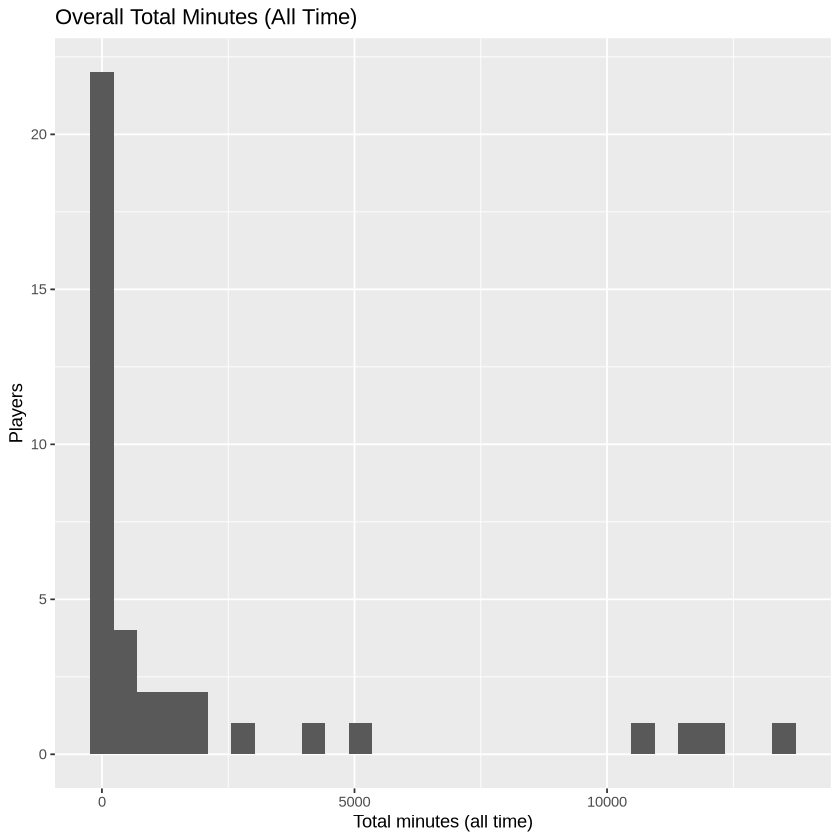

In [12]:
# distribution of overall minutes
ggplot(dat, aes(x = total_minutes_all)) +
  geom_histogram(bins = 30) +
  labs(title = "Overall Total Minutes (All Time)",
       x = "Total minutes (all time)", y = "Players")

The histogram shows that most players spend relatively little time on the server, while a small number play for much longer. This right-skewed distribution indicates that a minority of players contribute the majority of gameplay data. Such uneven participation supports focusing on early behavior to identify high contributing players early on.

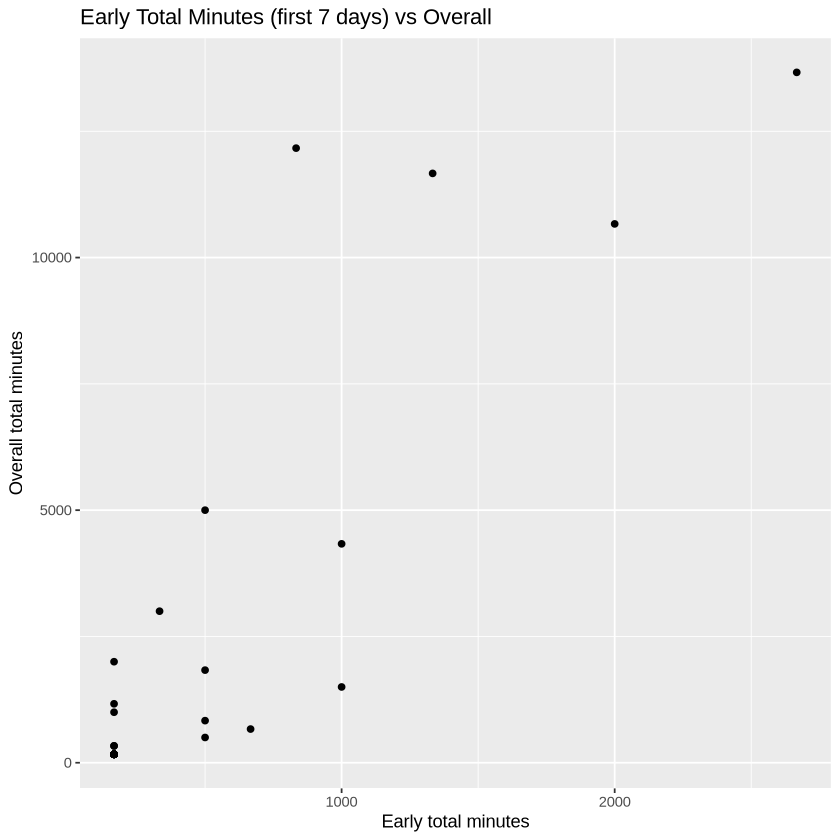

In [14]:
# relationship: early vs overall
ggplot(dat, aes(x = total_minutes_early, y = total_minutes_all)) +
  geom_point() +
  labs(title = "Early Total Minutes (first 7 days) vs Overall",
       x = "Early total minutes", y = "Overall total minutes")

This scatterplot suggests a positive but nonlinear relationship between the number of sessions and average session duration. Players with more sessions tend to spend slightly longer per session, implying higher engagement. However, variability increases among frequent players, meaning early consistency (not just session count) could be a stronger predictor of total playtime.

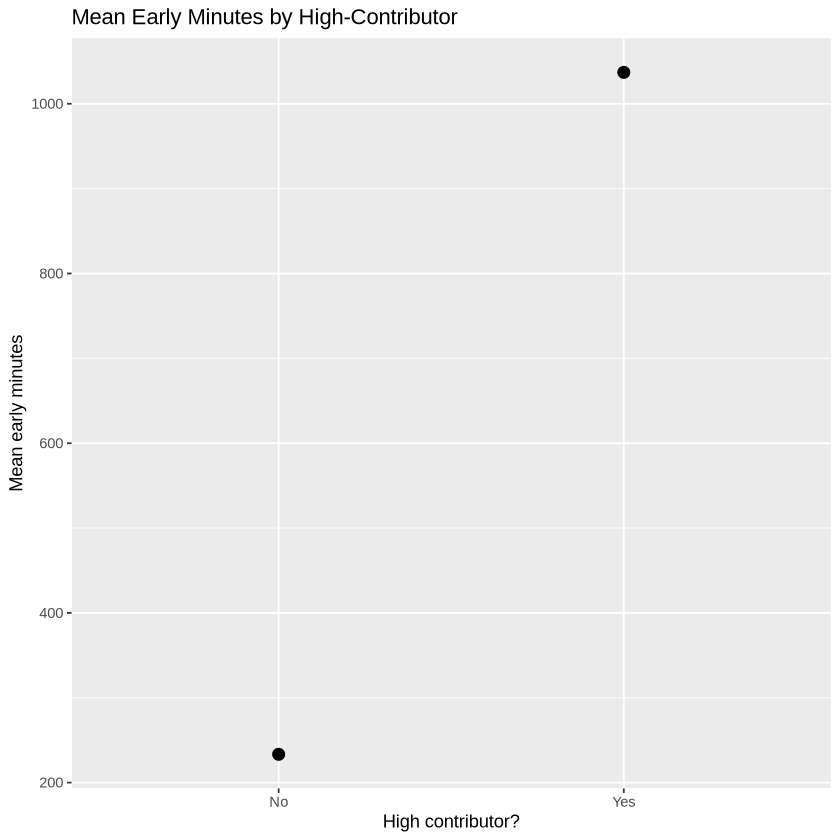

In [15]:
# group means (avoid boxplot): are early minutes higher for high contributors?
means_early <- dat |>
  group_by(high_contributor) |>
  summarise(mean_early = mean(total_minutes_early), .groups = "drop")

ggplot(means_early, aes(x = factor(high_contributor, labels = c("No","Yes")), y = mean_early)) +
  geom_point(size = 3) +
  labs(title = "Mean Early Minutes by High-Contributor",
       x = "High contributor?", y = "Mean early minutes")

High contributors spent substantially more time playing during their first week, suggesting that early engagement behavior strongly differentiates the most active players from the rest of the player base.

### (4) Method and plan
## Chosen Method: Linear Regression

To address the research question, I will use a linear regression model to explore whether early play behavior predicts total playtime. Linear regression is appropriate because the response variable, total minutes played, is continuous, and the model can quantify how strongly early activity influences overall engagement.

This method assumes a linear relationship between predictors and the response, independent observations, and limited outlier influence. Possible limitations include non-linearity or omitted variables that may affect player behavior. The data will be split into training and testing sets (70% - 30%) to evaluate model accuracy and avoid overfitting. Cross-validation will not be applied at this stage.